In [1]:
# !apt-get install gcc 
# !apt-get install -y cmake 

In [2]:
!pip show gcc cmake

Name: cmake
Version: 3.31.10
Summary: CMake is an open-source, cross-platform family of tools designed to build, test and package software
Home-page: https://cmake.org
Author: 
Author-email: Jean-Christophe Fillion-Robin <jchris.fillionr@kitware.com>
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import shutil
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

import tensorflow as tf

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, log_loss, ConfusionMatrixDisplay, RocCurveDisplay

import warnings

2026-05-10 20:30:25.130688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778445025.343813      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778445025.408225      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778445025.886622      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778445025.886665      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778445025.886667      16 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --

# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
class CFG():
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

tf.keras.utils.set_random_seed(CFG.SEED)

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    "axes.edgecolor":   '#444466',
    "axes.labelcolor":  '#e0e0ff',
    "text.color":       'lightblue',
    "xtick.color":      '#e0e0ff',
    "ytick.color":      '#e0e0ff',
    "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [7]:
display(train.head(10))
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
5,D012,HARD,Saudi Arabian Grand Prix,2022,0,35,2,26.0,5,93.734,-9.878,-98.041,0.500000,-3.0,1.0
6,D104,MEDIUM,Belgian Grand Prix,2023,0,23,2,16.0,11,114.937,-0.181,-11.904,0.333333,0.0,0.0
7,D082,HARD,United States Grand Prix,2022,0,41,3,9.0,1,100.211,-10.292,-53.799,0.569444,0.0,0.0
8,BEL,MEDIUM,Italian Grand Prix,2022,0,4,1,4.0,12,87.973,10.745,-32.929,0.111111,-9.0,0.0
9,YAM,MEDIUM,Hungarian Grand Prix,2023,0,2,1,2.0,8,84.726,-6.669,-6.669,0.028169,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [8]:
train.describe() 

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


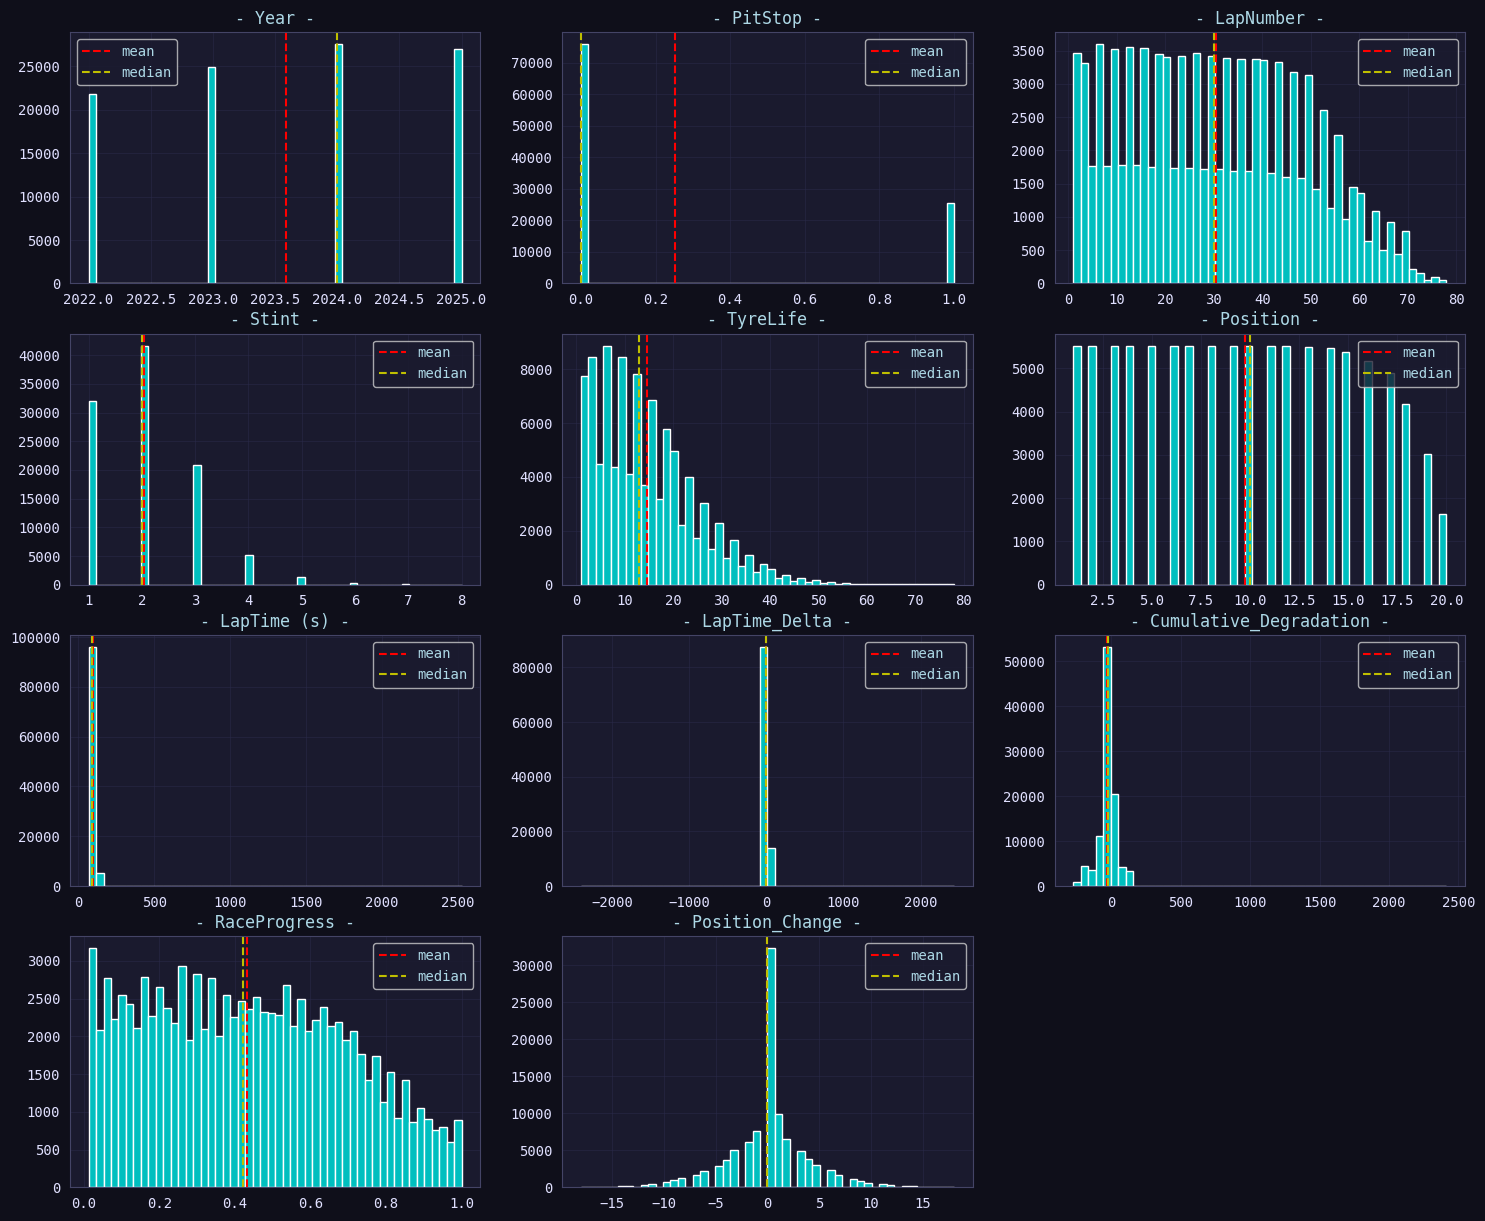

In [9]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()
    
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [11]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

## FEATURE ENGINEERING

In [12]:
## -- Optimal Binning --
try:
    import optbinning
except:
    %pip install -q -U optbinning
    import optbinning

def _opt_binning(
    x_tr, y_tr, x_vl, x_ts, bin_features, method='cart',
    solver='cp', metric='woe', pre_bins=20, period=100):
    """
    metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
    """
    x_train = x_tr.copy()
    x_valid = x_vl.copy()
    x_test  = x_ts.copy()

    for c in bin_features:
        if x_train[c].dtype in ['str', 'object', 'category']:
            combine  = pd.concat([x_train[c], x_valid[c], x_test[c]])
            combine  = combine.factorize()[0]
            # combine  = pd.Series(combine).astype('category')
            x_train[c] = combine[:len(x_train)]
            x_valid[c] = combine[len(x_train):len(x_train)+len(x_valid)]
            x_test[c]  = combine[-len(x_test):]

    opt_modules_per_col = []
    opt_cols = []

    # print(f'OptimalBinning {len(bin_features)}: ', end='')
    for col in tqdm(bin_features, desc='Optimal_Binning'):
        # print(f'{col}... ', end='')
        opt_b = optbinning.OptimalBinning(
            name=col,
            dtype='numerical',
            prebinning_method=method, # d='cart', 'quantile'
            # class_weight='balanced',
            # min_prebin_size=0.02, # d=0.05
            # cat_cutoff=0.01,
            solver=solver,
            max_n_prebins=pre_bins, # d=20
            # min_n_bins=2, max_n_bins=100,
            # min_bin_size=0.1, max_bin_size=0.9,
            time_limit=period, # d=100 (secs)
            # verbose=True,
        )

        opt_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())

        new_col = f'{col}_optBin'
        x_train[new_col] = opt_b.transform(x_train[col].to_numpy(), metric=metric)
        x_valid[new_col] = opt_b.transform(x_valid[col].to_numpy(), metric=metric)
        x_test[new_col]  = opt_b.transform(x_test[col].to_numpy(),  metric=metric)

        opt_cols.append(new_col)
        opt_modules_per_col.append(opt_b)

    return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

print('Binning function ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 22.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 5.26.1 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, b

In [13]:
opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_binning(
    x_tr=train,
    y_tr=train[TARGET],
    x_vl=orig,
    x_ts=test,
    bin_features=n_unique.index[-5:],
    method='cart', # 'cart', 'quantile'
    solver='cp', # 'cp', 'mip', 'ls'
    metric='event_rate', # 'woe','event_rate','indices','bins'
    # pre_bins=100,
    # period=100,
)

print(f"Total bin features: {len(opt_bin_cols)}")
train2.head()

Optimal_Binning:   0%|          | 0/5 [00:00<?, ?it/s]

Total bin features: 5


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Driver_optBin,RaceProgress_optBin,LapTime (s)_optBin,LapTime_Delta_optBin,Cumulative_Degradation_optBin
0,0,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,0.199762,0.319487,0.252153,0.284722,0.141025
1,1,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,0.199762,0.260135,0.252153,0.284722,0.472747
2,2,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,0.199762,0.116440,0.252153,0.284722,0.250347
3,3,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,0.199762,0.066597,0.146081,0.284722,0.141025
4,4,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,0.199762,0.260135,0.194241,0.256114,0.141025


Optimal Binned Features: 5


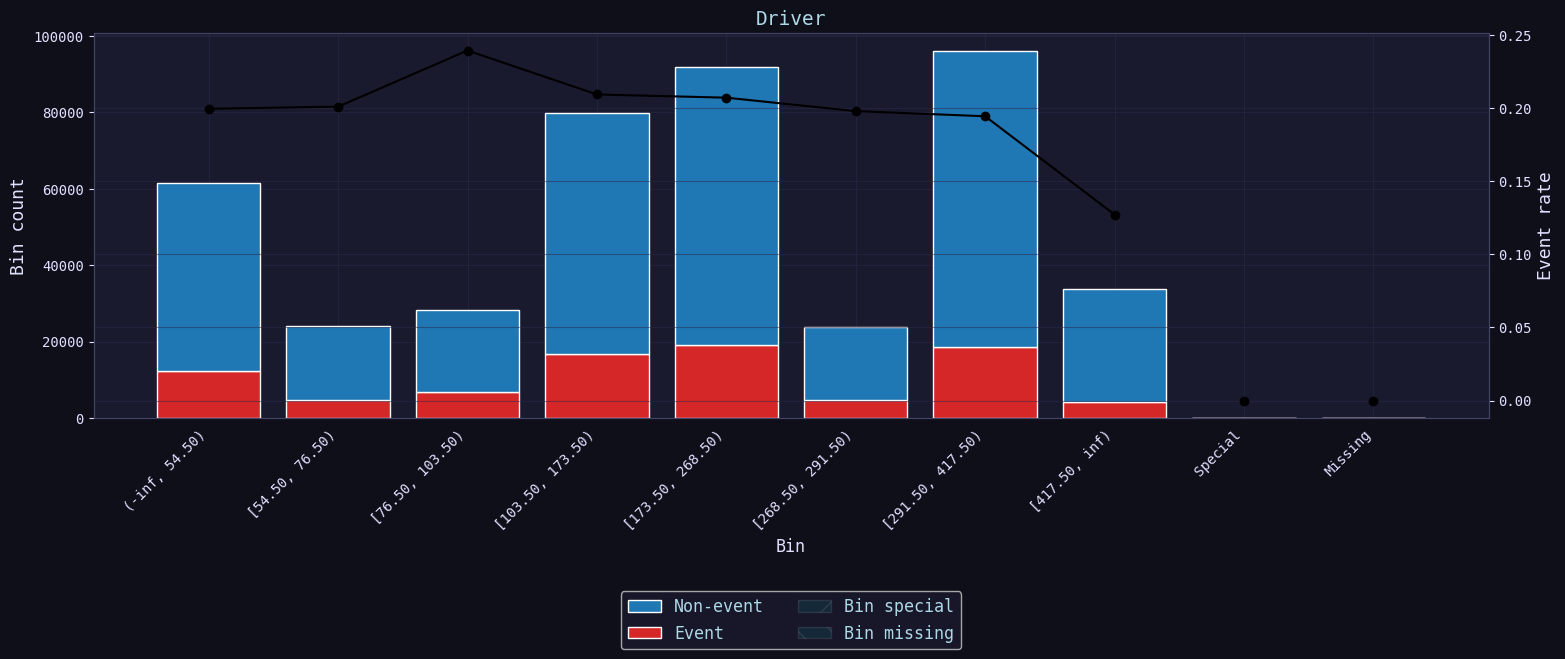

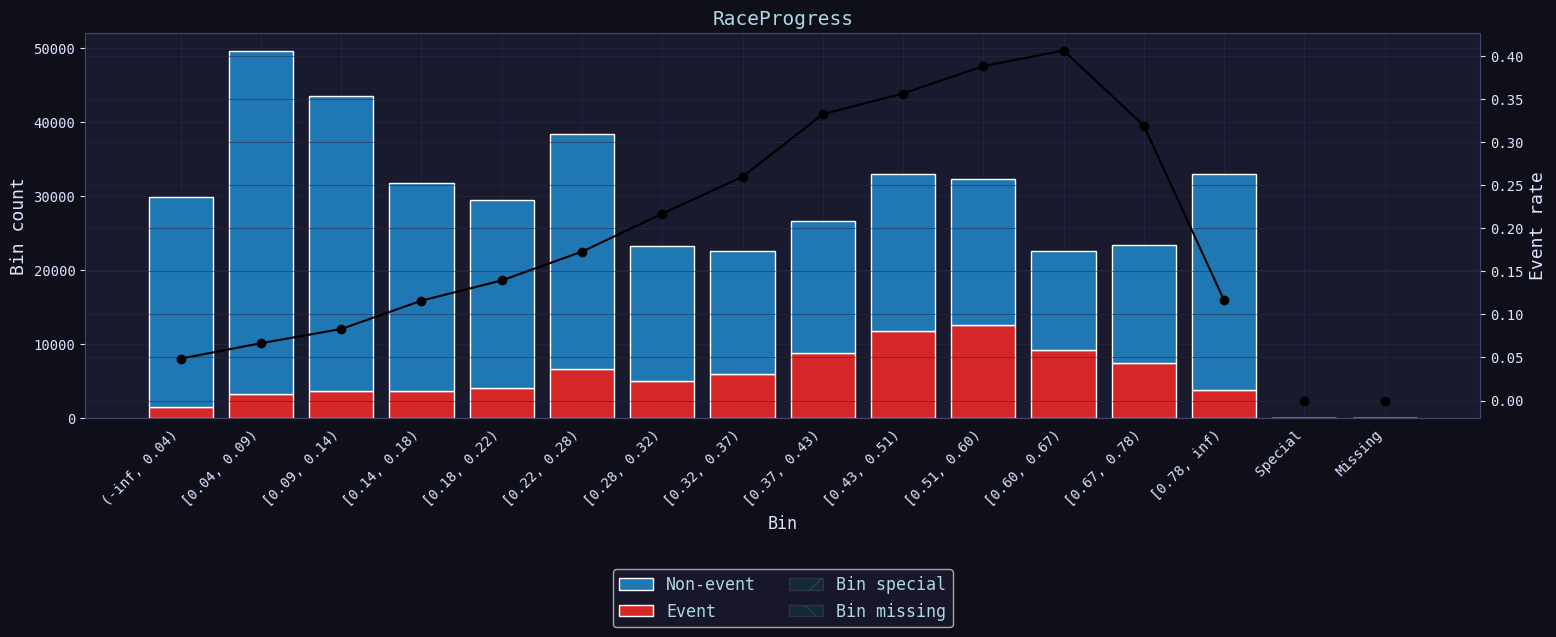

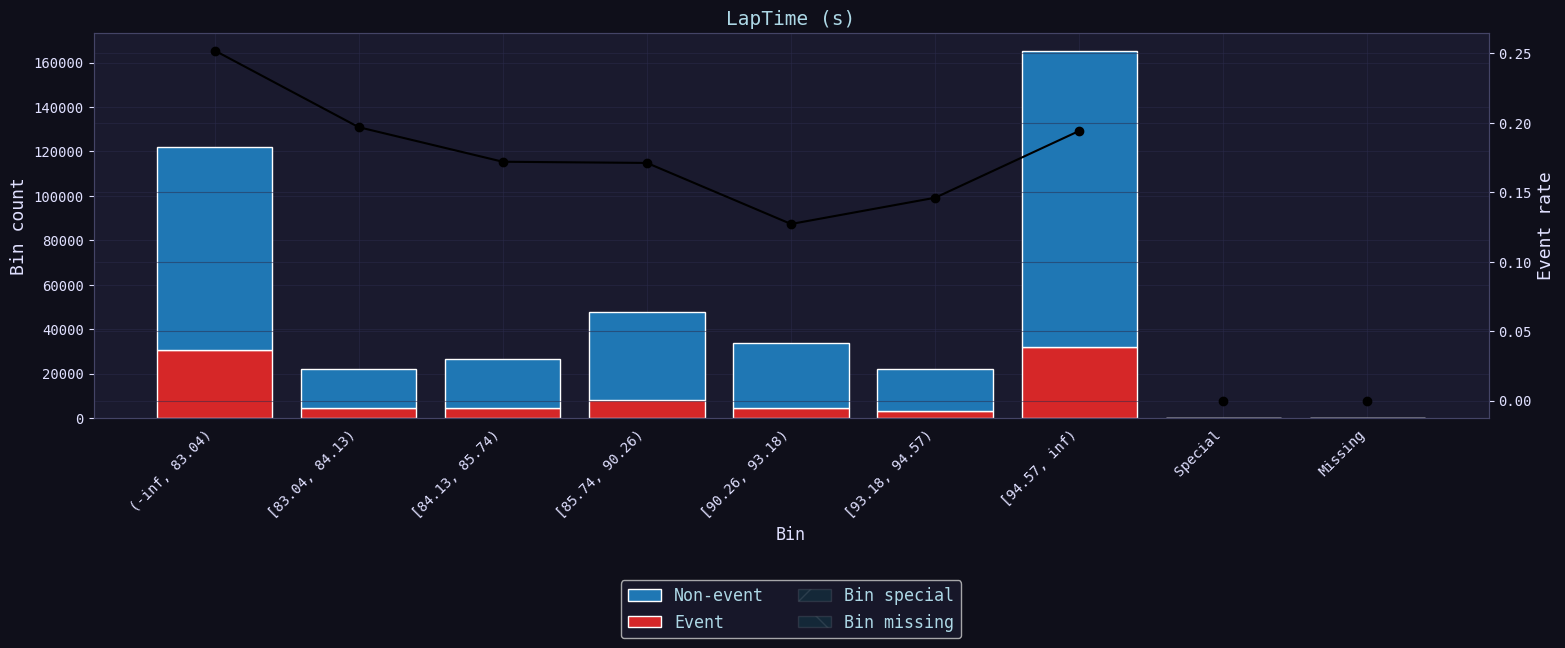

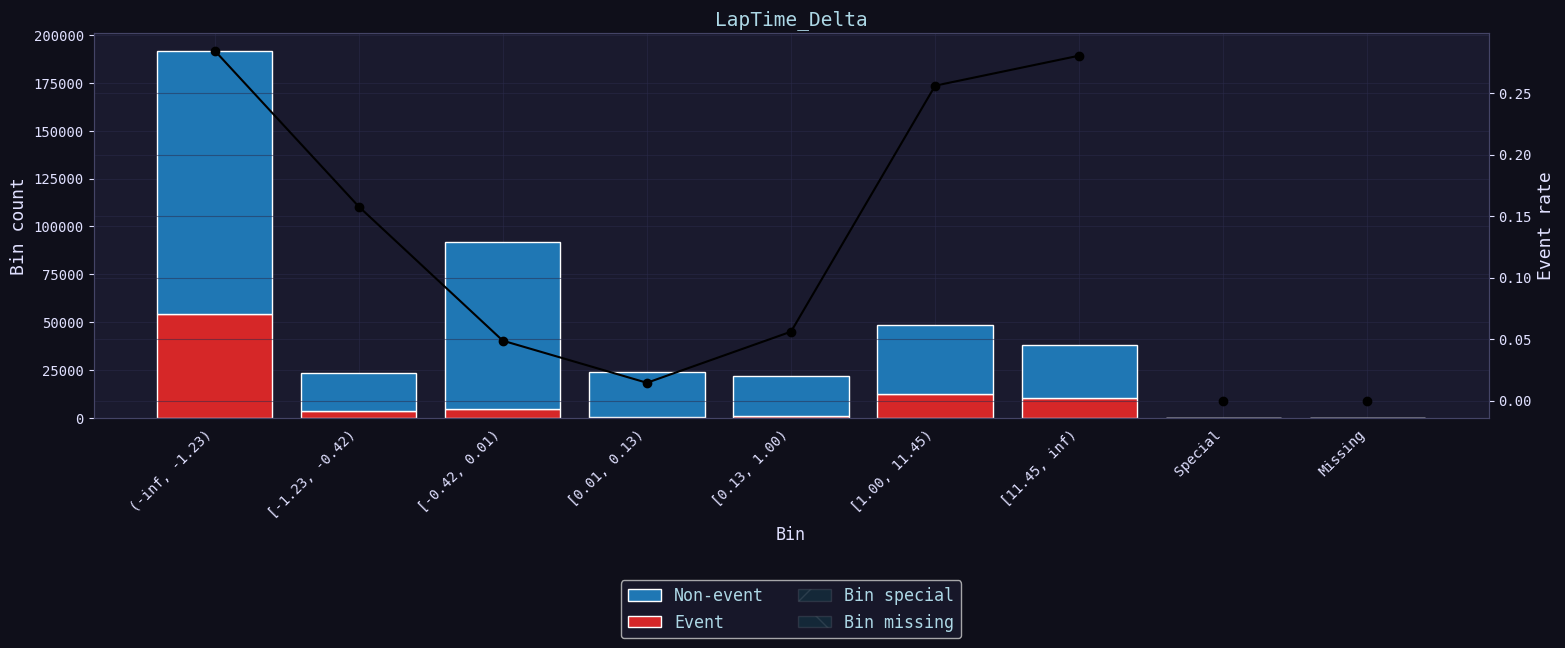

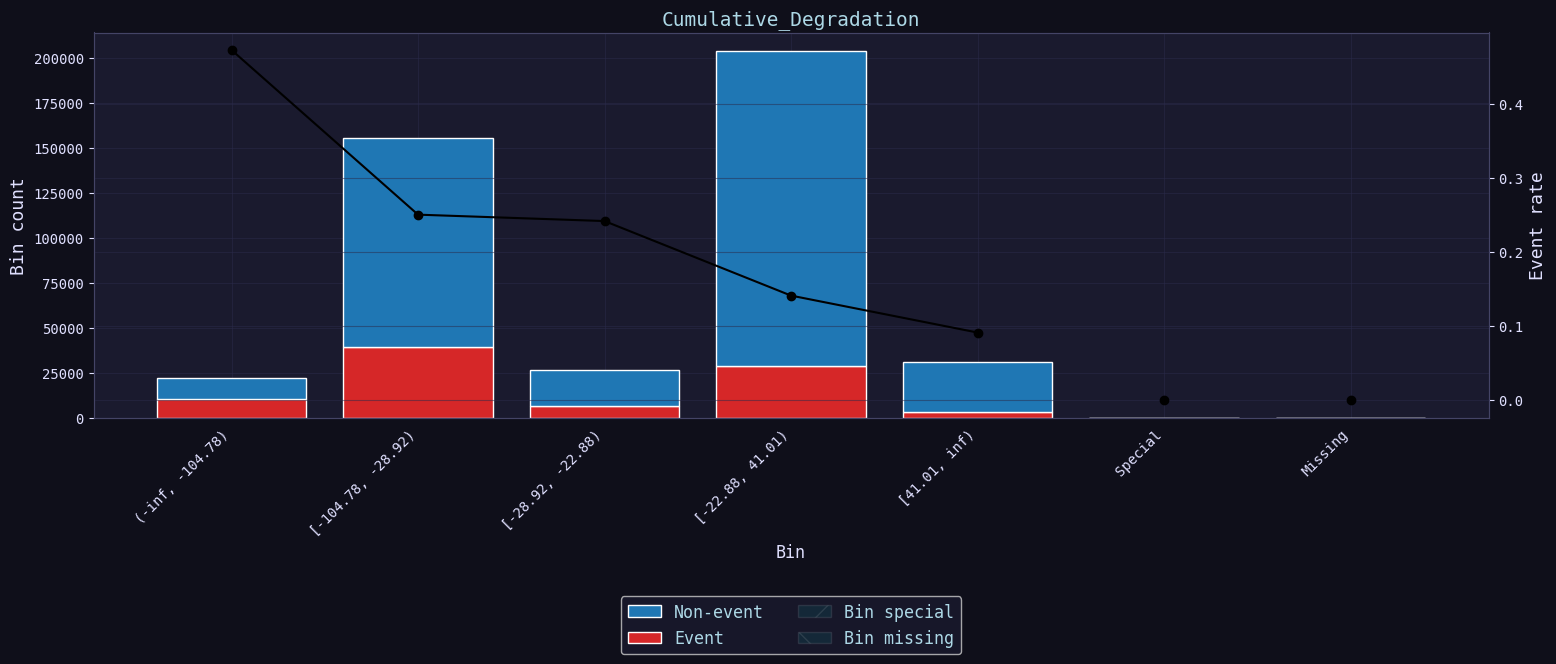

In [14]:
BIN_TABLES = []

for opt_ in opt_bins:
    opt_table = opt_.binning_table
    opt_table.build()
    BIN_TABLES.append(opt_table)

print('Optimal Binned Features:', len(BIN_TABLES))

## -- Plot optimal bin points --
for i, opt_ in enumerate(BIN_TABLES):
    opt_.plot(metric='event_rate', show_bin_labels=True, figsize=(18, 5))
    print()

In [15]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

print('- Sample_Weight function ready -')

- Sample_Weight function ready -


In [16]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [17]:
bin_cols = ['Cumulative_Degradation', 'LapTime (s)'] # 'LapTime_Delta'

print(f"\nRounding... ", end='')
for col in n_unique[n_unique > 1000].index.tolist():
    for r in range(-4, 7):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDIGITS... ", end='')
    # for d in [-3, -2, -1, 0, 1, 2, 3]:
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [10]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    print(f"\nCreating quantile-based Q_BINS... ", end='')
    for q in [10]:
        q_n = f'{col}_qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")

train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"\nFeatures dropped: {DROP_COLS}")


Rounding... RaceProgress_round_-4, RaceProgress_round_-3, RaceProgress_round_-2, RaceProgress_round_-1, RaceProgress_round_0, RaceProgress_round_1, RaceProgress_round_2, RaceProgress_round_3, RaceProgress_round_4, RaceProgress_round_5, RaceProgress_round_6, 
Creating quantile-based Q_BINS... RaceProgress_qbin_10, LapTime (s)_round_-4, LapTime (s)_round_-3, LapTime (s)_round_-2, LapTime (s)_round_-1, LapTime (s)_round_0, LapTime (s)_round_1, LapTime (s)_round_2, LapTime (s)_round_3, LapTime (s)_round_4, LapTime (s)_round_5, LapTime (s)_round_6, 
Creating quantile-based Q_BINS... LapTime (s)_qbin_10, LapTime_Delta_round_-4, LapTime_Delta_round_-3, LapTime_Delta_round_-2, LapTime_Delta_round_-1, LapTime_Delta_round_0, LapTime_Delta_round_1, LapTime_Delta_round_2, LapTime_Delta_round_3, LapTime_Delta_round_4, LapTime_Delta_round_5, LapTime_Delta_round_6, 
Creating quantile-based Q_BINS... LapTime_Delta_qbin_10, Cumulative_Degradation_round_-4, Cumulative_Degradation_round_-3, Cumulative_D

In [18]:
# print(f"\nRounding... ", end='')
# for col in ['LapTime (s)']:
#     for r in [-2, -1, 0, 1, 2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [0, 1, 2, 3, 4, 5, 6]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

# train = train.drop(columns=DROP_COLS)
# test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)
# print(f"\nFeatures dropped: {DROP_COLS}")

In [19]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

LapTime (s)_round_-3                 3
LapTime (s)_round_-2                 5
LapTime (s)_round_-1                25
LapTime (s)_round_0                137
LapTime (s)_round_1                134
LapTime (s)_round_2                132
LapTime (s)_round_3                132
LapTime (s)_round_4                132
LapTime (s)_round_5                132
LapTime (s)_round_6                132
LapTime_Delta_round_-3               3
LapTime_Delta_round_-2               9
LapTime_Delta_round_-1              43
LapTime_Delta_round_0              234
LapTime_Delta_round_1              222
LapTime_Delta_round_2              217
LapTime_Delta_round_3              217
LapTime_Delta_round_4              217
LapTime_Delta_round_5              217
LapTime_Delta_round_6              217
Cumulative_Degradation_round_-2      7
Cumulative_Degradation_round_-1     51
Cumulative_Degradation_round_0     454
Cumulative_Degradation_round_1     447
Cumulative_Degradation_round_2     445
Cumulative_Degradation_ro

In [20]:
def add_frequency_condition(df1, cols, replace_value=-1, thresh=5):
    df = df1.copy()

    for c in cols:
        v_counts = df[c].value_counts()
        to_replace = v_counts[v_counts <= thresh].index
        df[c] = np.where(df[c].isin(to_replace), replace_value, df[c])

    return df

for df in [train, test, orig]:
    df = add_frequency_condition(df, DIGITS+ROUNDS, -1, thresh=5)

print(f"Frequency threshold imputed!")

Frequency threshold imputed!


In [21]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(TOP_COLS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

# train[INTER].head(3)

In [22]:
sleep(5); gc.collect()

36002

In [23]:
# ## -- Arithmetic interaction --
# for df in [train, test, orig]:
#     df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
#     df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
#     df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

# arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
#               '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

# train[arithmetic].head()

In [24]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [25]:
# train['MonthlyCharges'].rolling(window=10000).mean().plot(figsize=(20, 5))

In [26]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in n_unique.index[4:]:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")

In [27]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [29]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [30]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Total original features: {len(ORIG_COLS)}")

In [31]:
# def engineer_f1_features(df1):
#     df = df1.copy()
#     # Ensure data is sorted by Race, Driver, and Lap to maintain temporal logic
#     df = df.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber'])

#     # 1. TRACKING STINT-SPECIFIC PERFORMANCE
#     # We group by Race, Year, Driver, and Stint to isolate the current set of tires
#     stint_group = df.groupby(['Year', 'Race', 'Driver', 'Stint'])

#     # Calculate the fastest lap achieved in the current stint (Stint Baseline)
#     df['Stint_Best_LapTime'] = stint_group['LapTime (s)'].transform('min')
    
#     # Calculate how much slower the current lap is compared to the stint's best (Pace Delta)
#     df['Delta_to_Stint_Best'] = df['LapTime (s)'] - df['Stint_Best_LapTime']

#     # 2. VOLATILITY & TRENDS (The "Struggling Driver" Proxy)
#     # Using a 3-lap rolling window to see if performance is becoming erratic
#     driver_group = df.groupby(['Year', 'Race', 'Driver'])
    
#     df['LapTime_Rolling_Std'] = driver_group['LapTime (s)'].transform(
#         lambda x: x.rolling(window=3, min_periods=1).std()
#     )
    
#     # Trend in degradation: Is the tire wearing out faster than the previous lap?
#     df['Degradation_Acceleration'] = driver_group['Cumulative_Degradation'].diff()

#     # 3. COMPOUND-SPECIFIC THRESHOLDS
#     # F1 compounds have different 'theoretical' limits. 
#     # We normalize TyreLife by the typical expected lifespan of the compound.
#     compound_map = {'HARD': 45, 'MEDIUM': 30, 'SOFT': 18} # Simplified heuristic
#     df['Expected_Max_Life'] = df['Compound'].map(compound_map)
#     df['Tyre_Life_Pct'] = df['TyreLife'] / df['Expected_Max_Life']

#     # 4. STRATEGIC POSITIONING
#     # The GAM plot showed Position_Change is impactful. 
#     # Let's see if the driver has been losing ground recently.
#     df['Recent_Position_Loss'] = driver_group['Position_Change'].transform(
#         lambda x: x.rolling(window=3, min_periods=1).sum()
#     )

#     # 5. CLEANUP
#     # Replace NaNs generated by rolling/diff with 0 or a neutral value
#     df.fillna(0, inplace=True)
    
#     # Drop redundancy: LapNumber and RaceProgress were 0.98 correlated in your heatmap
#     # We keep RaceProgress as it is a better normalized feature for XGBoost.
#     # if 'LapNumber' in df.columns:
#     #     df = df.drop(columns=['LapNumber'])

#     return df

# # Apply to your dataframe
# train = engineer_f1_features(train)
# test  = engineer_f1_features(test)
# orig  = engineer_f1_features(orig)

# NUMS_2 = train.iloc[:, -7:].columns.tolist()
# train.head()

In [32]:
## -- Duplicate all numerics as categories --
CATS_2 = []
nums_cats = [c for c in n_unique[n_unique < 1000].index.tolist() if c not in CATS]

for c in nums_cats:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n]  = test[c].copy()
    orig[n]  = orig[c].copy()
    CATS_2.append(n)

    ## -- Factorize --
    combine  = pd.concat([train[n], test[n], orig[n]])
    v = combine.factorize()[0]
    train[n] = v[:len(train)].astype('int32')
    test[n]  = v[len(train):len(train)+len(test)].astype('int32')
    orig[n]  = v[len(train)+len(test):].astype('int32')

print(f'Numericals to Categoricals: {len(CATS_2)}')

Numericals to Categoricals: 7


In [33]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [34]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(10)

Total Features: 54


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,RaceProgress_qbin_10,LapTime (s)_round_-3,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,LapTime (s)_round_3,LapTime (s)_round_4,LapTime (s)_round_5,LapTime (s)_round_6,LapTime (s)_qbin_10,LapTime_Delta_round_-3,LapTime_Delta_round_-2,LapTime_Delta_round_-1,LapTime_Delta_round_0,LapTime_Delta_round_1,LapTime_Delta_round_2,LapTime_Delta_round_3,LapTime_Delta_round_4,LapTime_Delta_round_5,LapTime_Delta_round_6,LapTime_Delta_qbin_10,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,Cumulative_Degradation_round_3,Cumulative_Degradation_round_4,Cumulative_Degradation_round_5,Cumulative_Degradation_round_6,Cumulative_Degradation_qbin_10,cat_PitStop,cat_Year,cat_Stint,cat_Position,cat_Position_Change,cat_LapNumber,cat_TyreLife
0,0,0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,8,0,100,80,78,78,78,78,78,78,78,1,0,0,-10,-8,-7,-7,-7,-7,-7,-7,2,0,20,21,21,21,21,21,21,21,9,0,0,0,0,0,0,0
1,1,0,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,5,0,100,80,75,75,75,75,75,75,75,0,0,0,-30,-33,-32,-32,-32,-32,-32,-32,0,-200,-220,-223,-223,-223,-223,-223,-223,-223,0,1,1,0,1,1,1,1
2,2,0,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,9,0,100,70,71,70,70,70,70,70,70,0,0,0,-10,-8,-7,-7,-7,-7,-7,-7,2,-100,-100,-101,-100,-100,-100,-100,-100,-100,0,0,0,1,2,2,2,2
3,3,1,3,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,1,0,100,90,94,94,94,94,94,94,94,6,0,0,-10,-7,-7,-7,-7,-7,-7,-7,2,0,-10,-7,-7,-7,-7,-7,-7,-7,7,0,2,2,3,3,3,3
4,4,0,4,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,6,0,100,110,108,107,107,107,107,107,107,9,0,0,10,9,9,8,8,8,8,8,8,0,-10,-14,-14,-14,-14,-14,-14,-14,6,1,0,1,4,2,4,4
5,5,0,5,2022,0,35,2,26.0,5,93.734,-9.878,-98.041,0.500000,-3.0,1.0,7,0,100,90,94,93,93,93,93,93,93,5,0,0,-10,-10,-9,-9,-9,-9,-9,-9,2,-100,-100,-98,-98,-98,-98,-98,-98,-98,0,0,0,0,5,1,5,5
6,6,1,6,2023,0,23,2,16.0,11,114.937,-0.181,-11.904,0.333333,0.0,0.0,5,0,100,110,115,114,114,114,114,114,114,9,0,0,0,0,0,0,0,0,0,0,5,0,-10,-12,-11,-11,-11,-11,-11,-11,6,0,2,0,6,3,6,6
7,7,0,7,2022,0,41,3,9.0,1,100.211,-10.292,-53.799,0.569444,0.0,0.0,7,0,100,100,100,100,100,100,100,100,100,8,0,0,-10,-10,-10,-10,-10,-10,-10,-10,2,-100,-50,-54,-53,-53,-53,-53,-53,-53,1,0,0,1,7,3,7,7
8,8,1,8,2022,0,4,1,4.0,12,87.973,10.745,-32.929,0.111111,-9.0,0.0,2,0,100,90,88,88,87,87,87,87,87,4,0,0,10,11,10,10,10,10,10,10,9,0,-30,-33,-32,-32,-32,-32,-32,-32,3,0,0,2,8,4,8,8
9,9,1,9,2023,0,2,1,2.0,8,84.726,-6.669,-6.669,0.028169,0.0,0.0,0,0,100,80,85,84,84,84,84,84,84,3,0,0,-10,-7,-6,-6,-6,-6,-6,-6,3,0,-10,-7,-6,-6,-6,-6,-6,-6,7,0,2,2,0,3,3,3


In [35]:
## -- CONVERT DATAFRAME TO .libffm FORMAT --
from collections import defaultdict

field_features   = defaultdict()

def df_to_libffm(df, cats, nums, target, save_file=f'df_converted.libffm'):
    '''
    Converts pandas dataframe to libffm formats, with feature dimension casting.
    '''
    categories       = cats
    categories_index = dict(zip(categories, range(len(categories))))
    max_val          = 1

    with open(save_file, 'a') as the_file:
        for t in tqdm(range(len(df))):
            row = df.iloc[t]
            label = [str(int(row[target]))]
            ffeatures = []
            for field in categories:
                if field == target:
                    continue 
                feature = row[field]
                if field not in nums:
                    ff = field + '_____' + str(feature)
                    value = 1
                else:
                    ff = field + '_____' + str(0)
                    value = feature
                if ff not in field_features:
                    if len(field_features) == 0:
                        field_features[ff] = 1
                        max_val = max_val + 1
                    else:
                        field_features[ff] = max_val + 1
                        max_val = max_val + 1
                fnum = field_features[ff]
                ffeatures.append('{}:{}:{}'.format(categories_index[field],fnum,value))
            line = label + ffeatures
            the_file.write('{}\n'.format(' '.join(line)))

In [36]:
%%writefile convert_libffm_format.py

## -- CONVERT DATAFRAME TO .libffm FORMAT --
import os
import shutil
import tempfile
import warnings
import numpy as np

def df_to_libffm_format(X, y, filepath='data.libffm', fields=None):
    """ Write data to xlearn format (libsvm or libffm). Modified from
    https://github.com/scikit-learn/scikit-learn/blob/a24c8b46/sklearn/datasets/svmlight_format.py

    :param X: array-like
              Feature matrix in numpy or sparse format
    :param y: array-like
              Label in numpy or sparse format
    :param filepath: file location for writing data to
    :param fields: An array specifying fields in each columns of X. It should have same length 
        as the number of columns in X. When set to None, convert data to libsvm format else
        libffm format.
    """

    with open(filepath, "wb") as f_handle:
        X_is_sp = int(hasattr(X, "tocsr"))
        y_is_sp = int(hasattr(y, "tocsr"))

        if X.dtype.kind == 'i':
            value_pattern = u"%d:%d"
        else:
            value_pattern = u"%d:%.16g"

        if fields is not None:
            is_ffm_format = True
            value_pattern = u"%d:" + value_pattern
        else:
            is_ffm_format = False

        if y.dtype.kind == 'i':
            label_pattern = u"%d"
        else:
            label_pattern = u"%.16g"

        line_pattern = u"%s %s\n"

        for i in range(X.shape[0]):
            if X_is_sp:
                span = slice(X.indptr[i], X.indptr[i + 1])
                x_indices = X.indices[span]
                row = zip(fields[x_indices], x_indices, X.data[span]) if is_ffm_format \
                    else zip(x_indices, X.data[span])
            else:
                nz = X[i] != 0
                row = zip(fields[nz], np.where(nz)[0], X[i, nz]) if is_ffm_format \
                    else zip(np.where(nz)[0], X[i, nz])

            if is_ffm_format:
                s = " ".join(value_pattern % (f, j, x) for f, j, x in row)
            else:
                s = " ".join(value_pattern % (j, x) for j, x in row)

            if y_is_sp:
                labels_str = label_pattern % y.data[i]
            else:
                labels_str = label_pattern % y[i]

            f_handle.write((line_pattern % (labels_str, s)).encode('ascii'))

Writing convert_libffm_format.py


# ML TRAINING

In [37]:
try:
    import xlearn
except:
    %pip install -q -U xlearn
    import xlearn

# try:
#     import skrub
# except:
#     %pip install -q skrub
#     import skrub

xlearn.hello()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [38]:
os.environ['USER'] = 'bill'

In [39]:
def Trainer_CV(model_name, params, arch_type, train_df, test_df, features, target, kf):
    print(f"\n========== Starting Cross-Validation for {model_name} ==========")
    start = time()

    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} - ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]

        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, count, std, nunique, median, max, min
        #     fill_nan=True,
        # )

        # cme = CategoryMeanTransformer(cat_cols=ROUNDS)
        # X_train = cme.fit_transform(X_train, y_train)
        # X_valid   = cme.transform(X_valid)
        # X_test  = cme.transform(X_test)

        # ce_cols = ['Driver', 'Race']
        # print(f" • Cat_Mean Encoding {len(ce_cols)} features...")
        # cm_enc  = CategoryMeanTransformer(cat_cols=ce_cols)
        # X_train = cm_enc.fit_transform(X_train, y_train)
        # X_valid = cm_enc.transform(X_valid)
        # X_test  = cm_enc.transform(X_test)
        # print()

        all_cats   = CATS + CATS_2 + Q_BINS + ROUNDS
        all_nums   = [c for c in X_train.columns if c not in all_cats]

        for col in all_nums:
            scaler = StandardScaler()
            X_train[col] = scaler.fit_transform(X_train[[col]], y_train)
            X_valid[col] = scaler.transform(X_valid[[col]])
            X_test[col]  = scaler.transform(X_test[[col]])

        # vector = skrub.TableVectorizer()
        # X_train = vector.fit_transform(X_train)
        # X_valid = vector.transform(X_valid)
        # X_test = vector.transform(X_test)

        # print(f"Vectorized shape: {X_train.shape} -")

        print(f"Train shape: {X_train.shape}")
        display(X_train.head(3))

        PATH_TRAIN = f"X_train_{idx}.libffm"
        df_to_libffm(pd.concat([X_train, y_train], axis=1), all_cats, all_nums, TARGET, PATH_TRAIN)

        PATH_VAL = f"X_val_{idx}.libffm"
        df_to_libffm(pd.concat([X_valid, y_valid], axis=1), all_cats, all_nums, TARGET, PATH_VAL)

        if arch_type == 'fm':
            model = xlearn.create_fm()
        elif arch_type == 'ffm':
            model = xlearn.create_ffm()
        else:
            model = xlearn.create_linear()

        model.setTrain(PATH_TRAIN)   
        model.setValidate(PATH_VAL)
        
        # model.setQuiet()
        # model.disableLockFree()
        # model.disableEarlyStop()
        # model.disableNorm()

        PATH_MODEL = f'model_{idx}.out'
        model.fit(params, PATH_MODEL)

        ## -- oof predictions --
        model = xlearn.create_linear()
        model.setTest(PATH_VAL)
        model.setSigmoid()

        PATH_OOF = f'oof_out_{idx}.txt'
        _ = model.predict(PATH_MODEL, PATH_OOF)
        oof_preds[val_idx] = pd.read_csv(PATH_OOF, sep=' ', header=None).to_numpy().ravel()

        ## -- test predictions --
        PATH_TEST = f"X_test_{idx}.libffm"
        pseudo_target = pd.Series(np.random.randint(0, 3, size=len(X_test)), name=TARGET)
        df_to_libffm(pd.concat([X_test, pseudo_target], axis=1), all_cats, all_nums, TARGET, PATH_TEST)

        model = xlearn.create_linear()
        model.setTest(PATH_TEST)
        model.setSigmoid()

        PATH_PRED = f'test_out_{idx}.txt'
        __ = model.predict(PATH_MODEL, PATH_PRED)
        test_preds += pd.read_csv(PATH_PRED, sep=' ', header=None).to_numpy().ravel()

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG.YELLOW} Fold {idx + 1} Score: {fold_score:.5f} {CFG.RESET}")

        ## -- Delete cache files --
        for file in [PATH_MODEL, PATH_TRAIN, PATH_VAL, PATH_TEST]:
            os.remove(file)
            # shutil.move(src, dst)

        files_directory = '/kaggle/working/'
        for filename in os.listdir(files_directory):
            if filename.endswith(('.libffm', '.bin', '.txt')):
                file_path = os.path.join(files_directory, filename)
                try:
                    if os.path.isfile(file_path) or os.path.islink(file_path): # Check if it is a file/link
                        os.remove(file_path)
                        # print(f"Deleted: {filename}")
                except OSError as e:
                    print(f"Error deleting {filename}: {e}")

        ## -- Clean up memory --
        del X_train, X_valid, y_train, y_valid, X_test
        gc.collect()
        torch.cuda.empty_cache()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- Print cv results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, s in enumerate(fold_scores):
        print(f" • Fold {i+1} score: {s:.5f}")

    ## -- CALCULATE OOF AUC --
    oof_score = np.round(roc_auc_score(y, oof_preds), 5)
    print("-------------------------------------------------|")
    print(f"Overall score: {oof_score}")
    print(f"Average score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
    }

print('⚙️⚙️ Train function ready ⚙️⚙️')

⚙️⚙️ Train function ready ⚙️⚙️


In [40]:
version_name = 'xlearn_v0_'
all_model_predictions = {}

MULTI_SEEDS = [CFG.SEED, 777, 1234, 24611, 0]

N_SPLITS = 5
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CFG.SEED)

kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [41]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,RaceProgress_qbin_10,LapTime (s)_round_-3,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,LapTime (s)_round_3,LapTime (s)_round_4,LapTime (s)_round_5,LapTime (s)_round_6,LapTime (s)_qbin_10,LapTime_Delta_round_-3,LapTime_Delta_round_-2,LapTime_Delta_round_-1,LapTime_Delta_round_0,LapTime_Delta_round_1,LapTime_Delta_round_2,LapTime_Delta_round_3,LapTime_Delta_round_4,LapTime_Delta_round_5,LapTime_Delta_round_6,LapTime_Delta_qbin_10,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,Cumulative_Degradation_round_3,Cumulative_Degradation_round_4,Cumulative_Degradation_round_5,Cumulative_Degradation_round_6,Cumulative_Degradation_qbin_10,cat_PitStop,cat_Year,cat_Stint,cat_Position,cat_Position_Change,cat_LapNumber,cat_TyreLife
55143,325,0,23,2025,0,3,3,6.0,18,81.919,-0.780,-22.988,0.052632,3.0,0.0,0,0,100,80,82,81,81,81,81,81,81,2,0,0,0,-1,0,0,0,0,0,0,4,0,-20,-23,-23,-22,-22,-22,-22,-22,4,0,1,1,10,2,18,4
157283,364,1,22,2023,0,9,1,9.0,3,84.336,0.163,-3.077,0.126761,0.0,0.0,2,0,100,80,84,84,84,84,84,84,84,3,0,0,0,0,0,0,0,0,0,0,7,0,0,-3,-3,-3,-3,-3,-3,-3,8,0,2,2,12,3,40,7
203881,110,1,17,2025,1,24,2,17.0,9,81.790,-13.936,-91.095,0.311688,8.0,0.0,5,0,100,80,82,81,81,81,81,81,81,2,0,0,-10,-14,-13,-13,-13,-13,-13,-13,1,-100,-90,-91,-91,-91,-91,-91,-91,-91,0,1,1,0,16,14,9,15


In [42]:
!rm -r /kaggle/working/

rm: cannot remove '/kaggle/working/': Device or resource busy


In [43]:
%%time

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

PARAMS = {
    'task': 'binary', # 'binary' | 'reg',
    'opt':'adagrad',
    'metric': 'auc',
    'lr': 0.2,
    'epoch': 50,
    'stop_window': 10, # Early Stopping
    'nthread': os.cpu_count(),
    # 'init': 0.8,  # default 0.66
    # 'alpha': 0.2,
    # 'lambda': 0.0001,
    # 'block_size': block_size,
    # 'seed': CFG.SEED,
}

for arch in ['ffm', 'fm', 'linear']: # 'ffm', 'fm', 'linear'
    n = version_name + arch
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        arch_type=arch,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
    ) 


========== Starting Cross-Validation for xlearn_v0_ffm ==========

***** FOLD 1/5 - Train shape: (351312, 54)


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,RaceProgress_qbin_10,LapTime (s)_round_-3,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,LapTime (s)_round_3,LapTime (s)_round_4,LapTime (s)_round_5,LapTime (s)_round_6,LapTime (s)_qbin_10,LapTime_Delta_round_-3,LapTime_Delta_round_-2,LapTime_Delta_round_-1,LapTime_Delta_round_0,LapTime_Delta_round_1,LapTime_Delta_round_2,LapTime_Delta_round_3,LapTime_Delta_round_4,LapTime_Delta_round_5,LapTime_Delta_round_6,LapTime_Delta_qbin_10,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,Cumulative_Degradation_round_3,Cumulative_Degradation_round_4,Cumulative_Degradation_round_5,Cumulative_Degradation_round_6,Cumulative_Degradation_qbin_10,cat_PitStop,cat_Year,cat_Stint,cat_Position,cat_Position_Change,cat_LapNumber,cat_TyreLife
0,0,0,0,-1.486898,-0.396691,1.585761,0.220848,2.539040,-0.307700,-0.642677,-0.085986,0.855917,1.487032,1.221360,8,0,100,80,78,78,78,78,78,78,78,1,0,0,-10,-8,-7,-7,-7,-7,-7,-7,2,0,20,21,21,21,21,21,21,21,9,0,0,0,0,0,0,0
1,1,0,1,1.440709,2.520853,0.229715,0.220848,-0.730239,-1.065329,-0.817853,-0.652949,-3.618198,0.033560,-0.773922,5,0,100,80,75,75,75,75,75,75,75,0,0,0,-30,-33,-32,-32,-32,-32,-32,-32,0,-200,-220,-223,-223,-223,-223,-223,-223,-223,0,1,1,0,1,1,1,1
2,2,0,2,-1.486898,-0.396691,2.116387,1.271885,0.802235,0.639335,-1.031923,-0.085443,-1.370790,1.902224,0.722539,9,0,100,70,71,70,70,70,70,70,70,0,0,0,-10,-8,-7,-7,-7,-7,-7,-7,2,-100,-100,-101,-100,-100,-100,-100,-100,-100,0,0,0,1,2,2,2,2


  0%|          | 0/351312 [00:00<?, ?it/s]

  0%|          | 0/87828 [00:00<?, ?it/s]

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary forma

...

  0%|          | 0/351312 [00:00<?, ?it/s]

  0%|          | 0/87828 [00:00<?, ?it/s]

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (X_train_4.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (X_val_4.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 6786
[------------] Time cost for reading problem: 3.99 (sec)
[ ACTION     ] Initialize model ...
[

  0%|          | 0/188165 [00:00<?, ?it/s]

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for prediction task.
[ ACTION     ] Load model ...
[------------] Load model from model_4.out
[------------] Loss function: cross-entropy
[------------] Score function: linear
[------------] Number of Feature: 6786
[------------] Time cost for loading model: 0.00 (sec)
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (X_test_4.libffm.bin) NOT found. Convert text file to binary file.
[------------] Time cost for reading problem: 1.74 (sec)
[ ACTION

In [44]:
# ==================================================
# Cross-Validation Results for xlearn_v0_ffm | auc, lr=0.2
# ==================================================
#  • Fold 1 score: 0.94563
#  • Fold 2 score: 0.94344
#  • Fold 3 score: 0.94530
#  • Fold 4 score: 0.94421
#  • Fold 5 score: 0.94509
# -------------------------------------------------|
# Overall score: 0.94472
# Average score: 0.94473 ± 0.00080
# -------------------------------------------------|
# 18.91 mins

In [45]:
# !ls /kaggle/working/

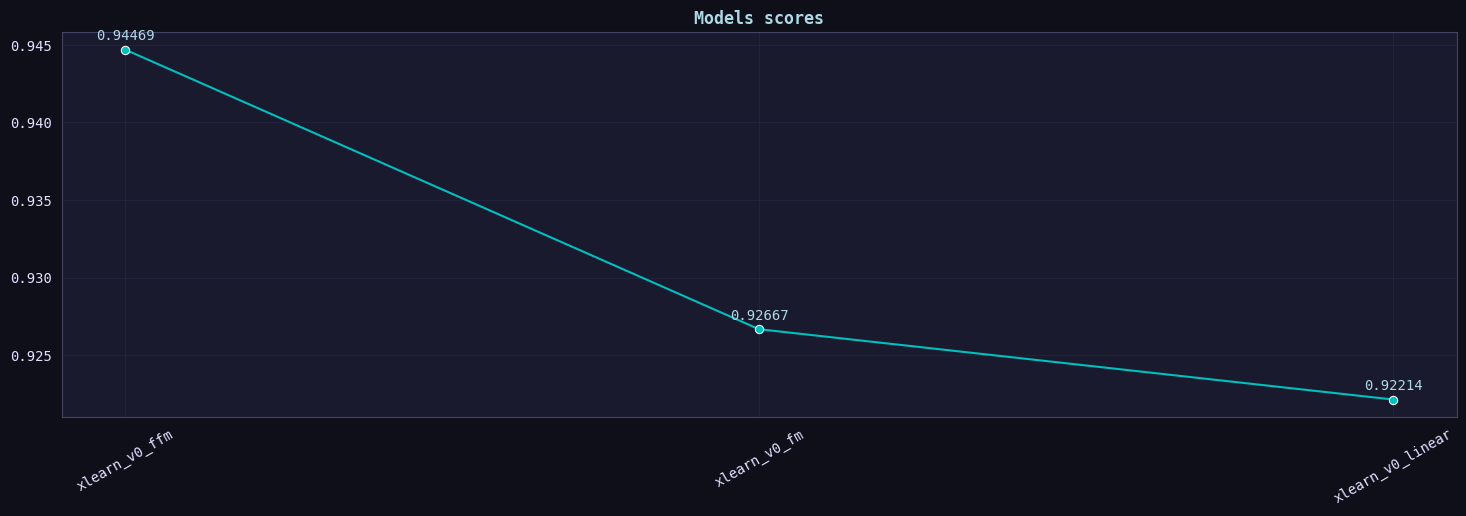

In [46]:
## -- Get Scores --
all_model_scores = {}
all_scores = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y
            all_scores.append(float(y))

plt.figure(figsize=(18, 5))
sns.lineplot(all_model_scores, marker='o')
plt.title('Models scores', fontweight='semibold')
plt.tick_params('x', rotation=30)

for i, s in enumerate(all_model_scores.values()):
    plt.text(float(i), s+1e-3, s, ha='center', va='center_baseline')

# plt.tight_layout()
plt.show()

xlearn_v0_ffm_94469 saved!


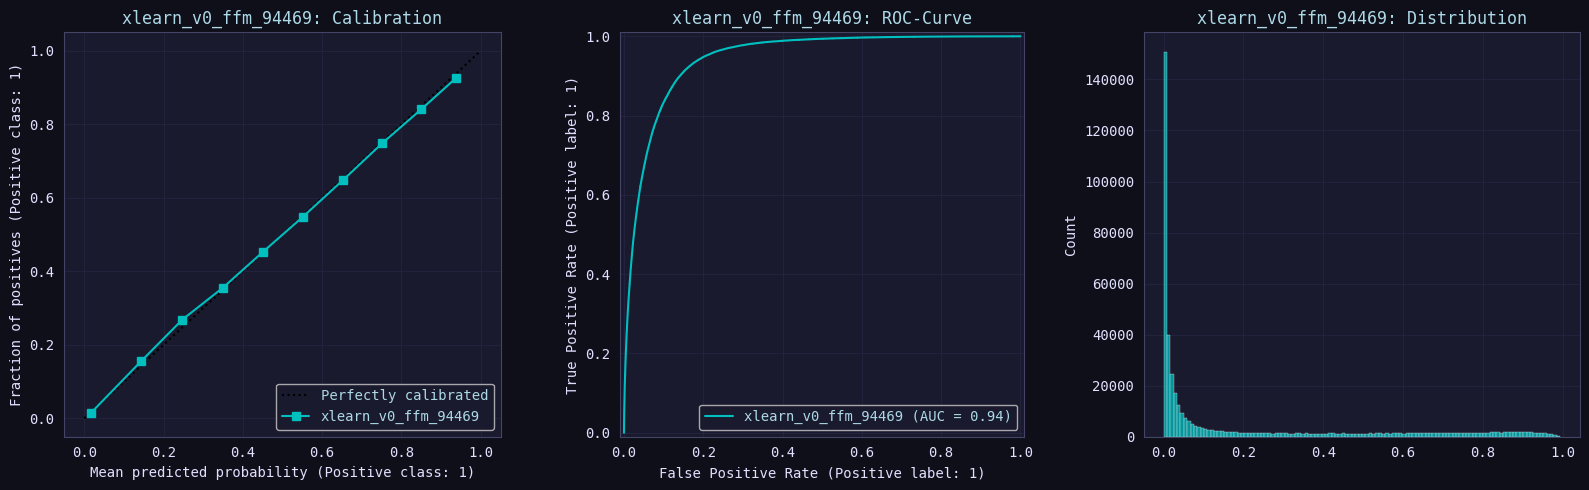


xlearn_v0_fm_92667 saved!


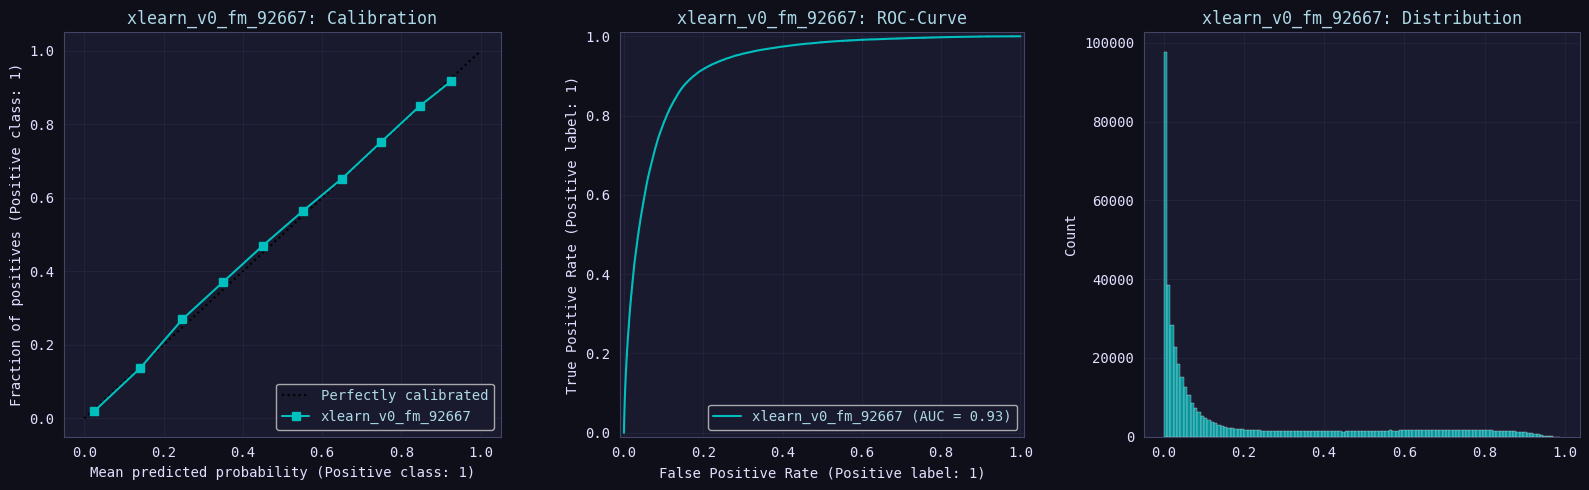


xlearn_v0_linear_92214 saved!


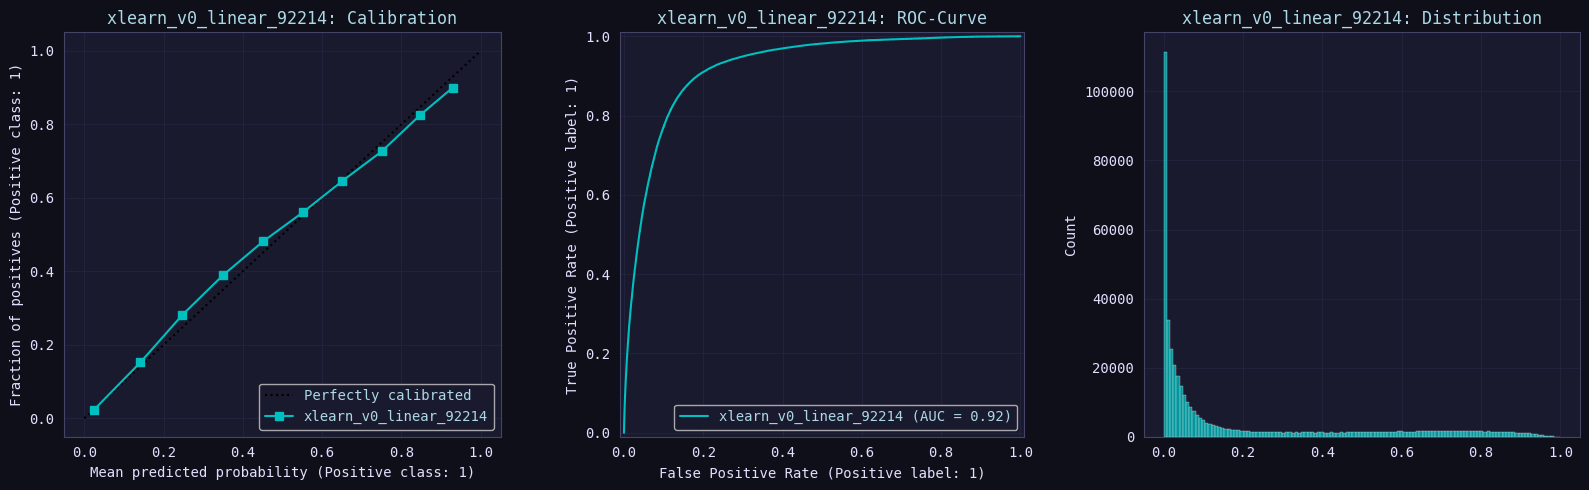

In [47]:
## -- Get oof predictions --
oof_preds = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}.npy", y)
            oof_preds[n] = y
            print(f'{n} saved!')
            
            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train[TARGET], y, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train[TARGET], y, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(y, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [48]:
## -- Save test predictions/submissions --
test_preds = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)
            test_preds[n] = y

            submit[TARGET] = y
            submit.to_csv(f'submit_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

submit.head(10)

xlearn_v0_ffm_94469 saved! (188165,)
xlearn_v0_fm_92667 saved! (188165,)
xlearn_v0_linear_92214 saved! (188165,)


,id,PitNextLap
0,439140,0.000469
1,439141,0.000618
2,439142,0.000993
3,439143,0.775783
4,439144,0.399292
5,439145,0.293913
6,439146,0.017960
7,439147,0.003741
8,439148,0.075863
9,439149,0.002142


In [49]:
# class LogisticRegression(tf.Module):

#   def __init__(self):
#     self.built = False

#   def __call__(self, x, train=True):
#     # Initialize the model parameters on the first call
#     if not self.built:
#       # Randomly generate the weights and the bias term
#       rand_w = tf.random.uniform(shape=[x.shape[-1], 1], seed=22)
#       rand_b = tf.random.uniform(shape=[], seed=22)
#       self.w = tf.Variable(rand_w)
#       self.b = tf.Variable(rand_b)
#       self.built = True
#     # Compute the model output
#     z = tf.add(tf.matmul(x, self.w), self.b)
#     z = tf.squeeze(z, axis=1)
#     if train:
#       return z
#     return tf.sigmoid(z)